In [1]:
%%capture
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
bridge_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/bridge_full_msg_csv.csv", low_memory=False)
seed_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/msgs_dataset.csv", low_memory=False)
domain_rating_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/domain_pc1.csv", low_memory=False)

combined_df = pd.concat([seed_df, bridge_df], ignore_index=True)

excluded_domains = []

columns_to_keep = [
    'channel_name', 'msg_id', 'message', 'cleaned_message', 'date', 
    'msg_link', 'has_url', 'url', 'domain', 'url_title', 'url_description'
]

## Combined Seed and Bridge channels' domain quality rating analysis ***(Full network)***

In [3]:
# Select only the columns to keep
combined_filtered_df = combined_df[columns_to_keep]
combined_filtered_df = combined_filtered_df[combined_filtered_df['has_url'] == 1 & ~combined_filtered_df['domain'].isin(excluded_domains)]

In [4]:
combined_filtered_df = combined_filtered_df.merge(domain_rating_df, on='domain', how='inner')
filtered_df_sorted = combined_filtered_df.sort_values(by='pc1', ascending=False)

average_pc1 = filtered_df_sorted['pc1'].mean()

# print("Filtered and Sorted DataFrame:")
# print(filtered_df_sorted[['domain', 'pc1', 'channel_name', 'msg_id', 'msg_link']])

print("\nAverage PC1 Score of full network:", average_pc1)


Average PC1 Score of full network: 0.4673981770307969


In [5]:
domain_frequencies = filtered_df_sorted['domain'].value_counts()
domain_frequencies

domain
youtube.com                3221
ria.ru                      330
facebook.com                 97
nytimes.com                  89
n-tv.de                      64
                           ... 
juedische-allgemeine.de       1
mopo.de                       1
ndtv.com                      1
presseportal.de               1
lejsl.com                     1
Name: count, Length: 289, dtype: int64

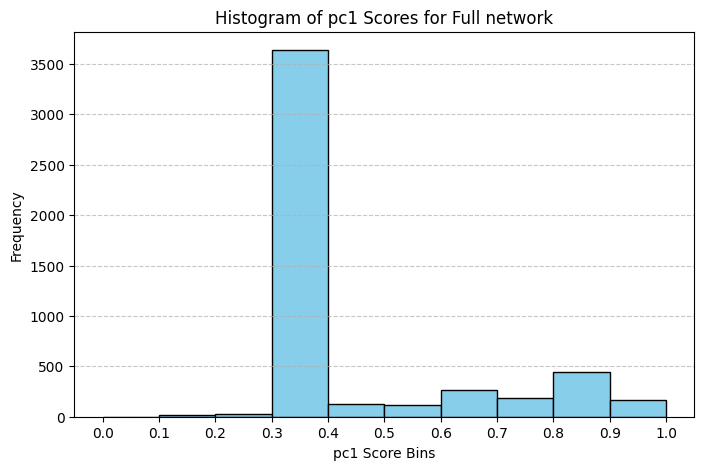

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(filtered_df_sorted["pc1"], bins=10, range=(0, 1), edgecolor='black', color='skyblue')
plt.title("Histogram of pc1 Scores for Full network")
plt.xlabel("pc1 Score Bins")
plt.ylabel("Frequency")
plt.xticks([i/10 for i in range(11)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Domain quality rating analysis after removing top 3 bridge channels ***(sub_network)***

In [7]:
top_bridge_channels = ['warfakebelgorod', 'zarussia_1', 'ua_tribunal']
top_bridge_excluded_df = bridge_df[~bridge_df['channel_name'].isin(top_bridge_channels)]

In [8]:
subnetwork_df = pd.concat([seed_df, top_bridge_excluded_df], ignore_index=True)

# Select only the columns to keep
subnetwork_filtered_df = subnetwork_df[columns_to_keep]

subnetwork_filtered_df = subnetwork_filtered_df[subnetwork_filtered_df['has_url'] == 1 & ~subnetwork_filtered_df['domain'].isin(excluded_domains)]

In [9]:
subnetwork_filtered_df = subnetwork_filtered_df.merge(domain_rating_df, on='domain', how='inner')
subnetwork_filtered_df_sorted = subnetwork_filtered_df.sort_values(by='pc1', ascending=False)

average_pc1_subnetwork = subnetwork_filtered_df_sorted['pc1'].mean()

print("\nAverage PC1 Score of sub-network:", average_pc1_subnetwork)


Average PC1 Score of sub-network: 0.46701701773872867


In [10]:
domain_frequencies_subnetwork = subnetwork_filtered_df_sorted['domain'].value_counts()
domain_frequencies_subnetwork

domain
youtube.com             3218
ria.ru                   329
facebook.com              97
nytimes.com               89
n-tv.de                   64
                        ... 
sltrib.com                 1
sciencedirect.com          1
popularmechanics.com       1
defenseone.com             1
nzherald.co.nz             1
Name: count, Length: 289, dtype: int64

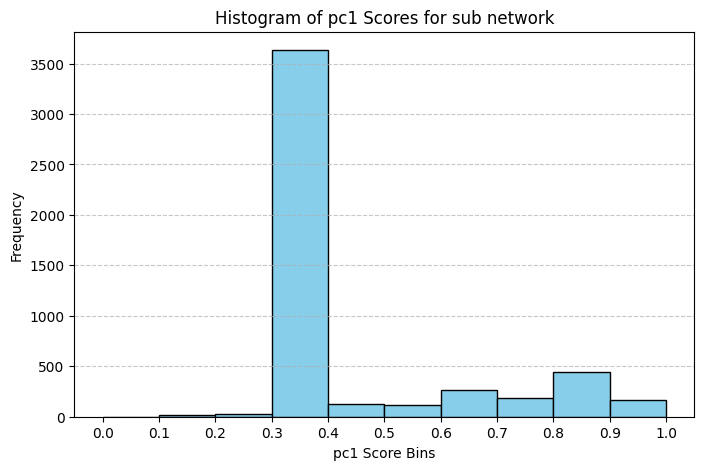

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(subnetwork_filtered_df_sorted["pc1"], bins=10, range=(0, 1), edgecolor='black', color='skyblue')
plt.title("Histogram of pc1 Scores for sub network")
plt.xlabel("pc1 Score Bins")
plt.ylabel("Frequency")
plt.xticks([i/10 for i in range(11)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Domain quality rating analysis of bridge channels

In [12]:
# Select only the columns to keep
bridge_filtered_df = bridge_df[columns_to_keep]

bridge_filtered_df = bridge_filtered_df[bridge_filtered_df['has_url'] == 1 & ~bridge_filtered_df['domain'].isin(excluded_domains)]

In [13]:
bridge_filtered_df = bridge_filtered_df.merge(domain_rating_df, on='domain', how='inner')
bridge_filtered_df_sorted = bridge_filtered_df.sort_values(by='pc1', ascending=False)

average_pc1_bridge = bridge_filtered_df_sorted['pc1'].mean()

print("\nAverage PC1 Score of bridge channels:", average_pc1_bridge)


Average PC1 Score of bridge channels: 0.6096070880463776


In [14]:
domain_frequencies_bridge = bridge_filtered_df_sorted['domain'].value_counts()
domain_frequencies_bridge[0:10]

domain
youtube.com        56
nytimes.com         8
theguardian.com     6
edition.cnn.com     6
facebook.com        5
politico.com        5
ria.ru              5
wsj.com             5
newsweek.com        4
reuters.com         4
Name: count, dtype: int64

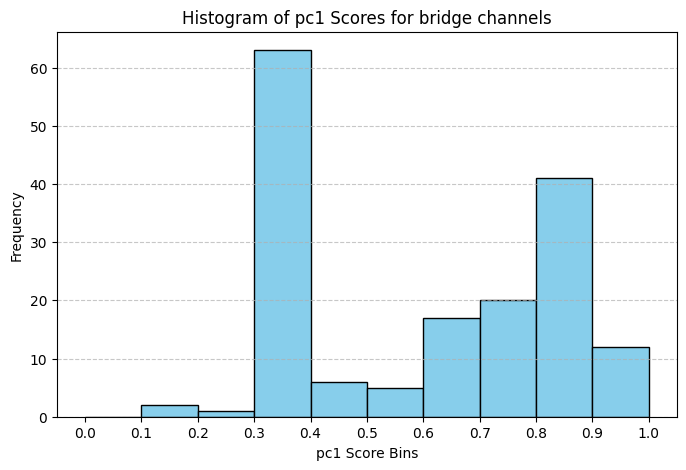

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(bridge_filtered_df_sorted["pc1"], bins=10, range=(0, 1), edgecolor='black', color='skyblue')
plt.title("Histogram of pc1 Scores for bridge channels")
plt.xlabel("pc1 Score Bins")
plt.ylabel("Frequency")
plt.xticks([i/10 for i in range(11)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Domain quality rating analysis of seed channels

In [16]:
seed_filtered_df = seed_df[columns_to_keep]

seed_filtered_df = seed_filtered_df[seed_filtered_df['has_url'] == 1 & ~seed_filtered_df['domain'].isin(excluded_domains)]

In [17]:
seed_filtered_df = seed_filtered_df.merge(domain_rating_df, on='domain', how='inner')
seed_filtered_df_sorted = seed_filtered_df.sort_values(by='pc1', ascending=False)

average_pc1_seed = seed_filtered_df_sorted['pc1'].mean()

print("\nAverage PC1 Score of seed channels:", average_pc1_seed)


Average PC1 Score of seed channels: 0.46246795321107476


In [18]:
domain_frequencies_seed = seed_filtered_df_sorted['domain'].value_counts()
domain_frequencies_seed

domain
youtube.com        3165
ria.ru              325
facebook.com         92
nytimes.com          81
n-tv.de              64
                   ... 
harpers.org           1
bellingcat.com        1
theatlantic.com       1
stopfake.org          1
bz-berlin.de          1
Name: count, Length: 279, dtype: int64

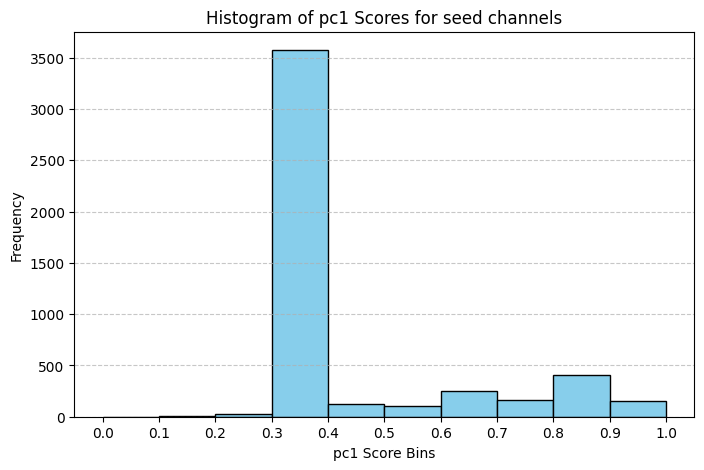

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(seed_filtered_df_sorted["pc1"], bins=10, range=(0, 1), edgecolor='black', color='skyblue')
plt.title("Histogram of pc1 Scores for seed channels")
plt.xlabel("pc1 Score Bins")
plt.ylabel("Frequency")
plt.xticks([i/10 for i in range(11)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Comparative results

In [20]:
percent_difference = abs(average_pc1_subnetwork - average_pc1) / ((average_pc1_subnetwork + average_pc1) / 2) * 100
print("Percent difference in domain quality pc1 ratings of full-network & sub-network: ",percent_difference)

Percent difference in domain quality pc1 ratings of full-network & sub-network:  0.08158242592838745


In [21]:
percent_difference = abs(average_pc1_seed - average_pc1) / ((average_pc1_seed + average_pc1) / 2) * 100
print("Percent difference in domain quality pc1 ratings of full-network & seed-network: ",percent_difference)

Percent difference in domain quality pc1 ratings of full-network & seed-network:  1.0604158296290913


In [22]:
percent_difference = abs(average_pc1_bridge - average_pc1) / ((average_pc1_bridge + average_pc1) / 2) * 100
print("Percent difference in domain quality pc1 ratings of full-network & bridge-network: ",percent_difference)

Percent difference in domain quality pc1 ratings of full-network & bridge-network:  26.40821092093557


In [23]:
percent_difference = abs(average_pc1_bridge - average_pc1_seed) / ((average_pc1_bridge + average_pc1_seed) / 2) * 100
print("Percent difference in domain quality pc1 ratings of seed-network & bridge-network: ",percent_difference)

Percent difference in domain quality pc1 ratings of seed-network & bridge-network:  27.449409635116815
